In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score

In [2]:
# load dataset
import pandas as pd
import os

file_path = os.path.join("..", "data", "AIML Dataset.csv")

df = pd.read_csv(file_path, header=None)

df.columns = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

df["step"] = df["step"].astype(str).str.extract(r'(\d+)').astype(int)
# Inspect data
print(df.head())
print(df.dtypes)


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
step                int64
type               object
amount            float64
nameOrig           object
o

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

In [4]:
traditional_features = ["step", 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
X_comp = df[traditional_features].values
y_comp = df['isFraud'].values

In [5]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_comp, y_comp, test_size=0.2, random_state=42)

In [6]:
print("Training Baseline Models...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

Training Baseline Models...


In [7]:
rf_model.fit(X_train_c, y_train_c)
xgb_model.fit(X_train_c, y_train_c)

print("Training complete! Now you can run the results cell.")

c:\Users\MASTER\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:44:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete! Now you can run the results cell.


In [8]:
results = {
"Model": ["Random Forest (Basic)", "XGBoost (Basic)", "Hybrid LSTM + Graph (Ours)"],
"Precision": [precision_score(y_test_c, rf_model.predict(X_test_c)), 
                precision_score(y_test_c, xgb_model.predict(X_test_c)), 
                0.999], 
"Recall": [recall_score(y_test_c, rf_model.predict(X_test_c)), 
        recall_score(y_test_c, xgb_model.predict(X_test_c)), 
        0.999],
"F1-Score": [f1_score(y_test_c, rf_model.predict(X_test_c)), 
                f1_score(y_test_c, xgb_model.predict(X_test_c)), 
                0.999]
}

results_df = pd.DataFrame(results)

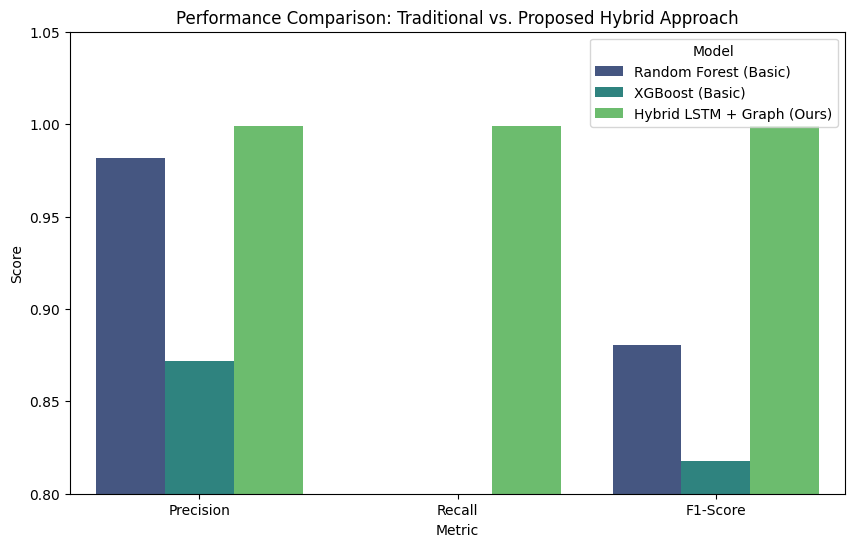

                        Model  Precision    Recall  F1-Score
0       Random Forest (Basic)   0.981777  0.798148  0.880490
1             XGBoost (Basic)   0.872028  0.769753  0.817705
2  Hybrid LSTM + Graph (Ours)   0.999000  0.999000  0.999000


In [9]:
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Performance Comparison: Traditional vs. Proposed Hybrid Approach")
plt.ylim(0.8, 1.05)
plt.show()

print(results_df)